# Erkennung der Schweißqualität während des Schweißprozesses

## Entwicklung eines datengetriebenen Verfahrens zur Überwachung und Vorhersage der Schweißqualität anhand von induktiven Tasterdaten und thermischen LWIR-Aufnahmen

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import math

## Taster-Zeitreihen analysieren:

##### -> Wie bewegen sich Probe 1, 2 und 3 während einer Schweißung?

In [21]:
pfad001_000Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")

fuerDataFrame = np.load(pfad001_000Prep)

df001_000Prep = pd.DataFrame(
    {
        "Time (s)": fuerDataFrame[0],
        "Taster 1 (mm)": fuerDataFrame[1],
        "Taster 2 (mm)": fuerDataFrame[2],
        "Taster 3 (mm)": fuerDataFrame[3]
    }
)

display(df001_000Prep[: 100])

print(df001_000Prep.shape)

,Time (s),Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,1.134,0.020373,0.012720,0.003004
1,1.135,0.020452,0.012877,0.003161
2,1.136,0.020530,0.013034,0.003396
3,1.137,0.020687,0.013270,0.003553
4,1.138,0.020530,0.013505,0.003710
...,...,...,...,...
95,1.229,0.032382,0.051413,0.069559
96,1.230,0.032539,0.051806,0.070501
97,1.231,0.032539,0.052198,0.071050
98,1.232,0.032853,0.052905,0.071757


(19909, 4)


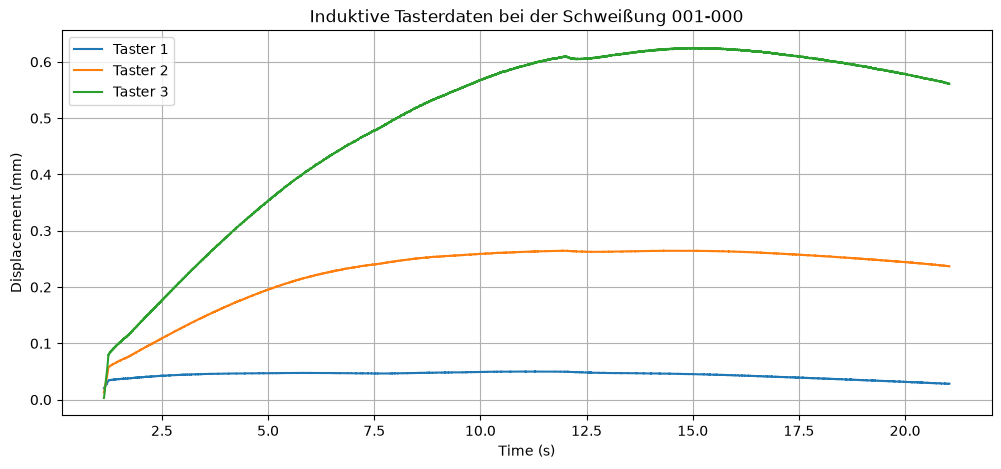

In [22]:
plt.figure(figsize = (12, 5))

plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 1 (mm)"], label="Taster 1")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 2 (mm)"], label="Taster 2")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 3 (mm)"], label="Taster 3")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (mm)")
plt.title("Induktive Tasterdaten bei der Schweißung 001-000")
plt.legend()
plt.grid()

plt.show()

##### -> Starke Positionsänderungen in Y-Richtung vor allem bei Taster 3. Taster 3 befindet sich an der rechten bzw. endseitigen Messposition des beweglichen Blechs.